In [9]:
!pip install imbalanced-learn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

In [11]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [16]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [18]:
df['TravelDate'] = pd.date_range(
    start='1912-01-01',
    periods=len(df),
    freq='D'
)

In [19]:
df['Year'] = df['TravelDate'].dt.year
df['Month'] = df['TravelDate'].dt.month
df['Day'] = df['TravelDate'].dt.day

In [21]:
df['Age_Fare'] = df['Age'] * df['Fare']

In [22]:
X = df[['Pclass',
        'Sex',
        'Age',
        'Fare',
        'Embarked',
        'Year',
        'Month',
        'Day',
        'Age_Fare']]

y = df['Survived']

In [24]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print(y_train.value_counts())

Survived
0    444
1    268
Name: count, dtype: int64


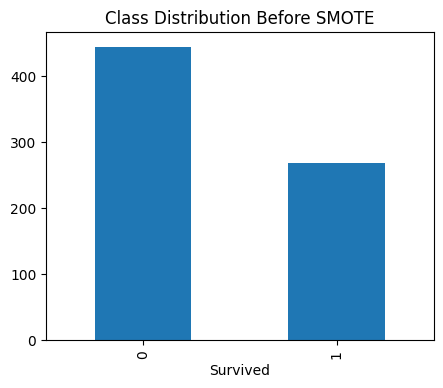

In [29]:
plt.figure(figsize=(5,4))

y_train.value_counts().plot(kind='bar')

plt.title("Class Distribution Before SMOTE")

plt.show()

In [30]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [31]:
print(y_train_smote.value_counts())

Survived
0    444
1    444
Name: count, dtype: int64


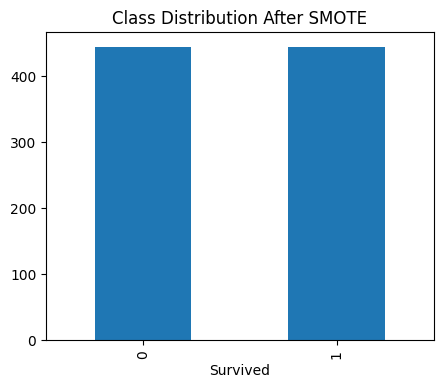

In [32]:
plt.figure(figsize=(5,4))

y_train_smote.value_counts().plot(kind='bar')

plt.title("Class Distribution After SMOTE")

plt.show()

In [33]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [34]:
prediction = model.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [36]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       105
           1       0.72      0.85      0.78        74

    accuracy                           0.80       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.82      0.80      0.81       179



In [37]:
assert accuracy > 0.70

print("All Tests Passed Successfully!")

All Tests Passed Successfully!
